# Библиотека Pandas



[Официальный сайт библиотеки](https://pandas.pydata.org/)

[Руководство пользователя 1](https://pythonist.ru/polnoe-rukovodstvo-po-pandas-dlya-nachinayushhih/)

[Руководство пользователя 2](https://pandas.pydata.org/docs/user_guide/index.html)


Pandas — одна из самых популярных Python-библиотек для аналитики и работы с Data Science. Можно сказать, что её роль в задачах обработки данных в Python аналогична роли систем SQL — потому, что Pandas предлагает развитый функционал для разнообразных операций с табличными данными.

Pandas работает с объектами двух основных типов: ***DataFrame*** и ***Series***.

Основной из них — DataFrame. Это двумерная таблица, в которой каждая строка имеет уникальный индекс (обычно - порядковый номер). Series — столбец такой  таблицы (одномерный объект), который может рассматриваться и как часть DataFrame, и как самостоятельный объект.
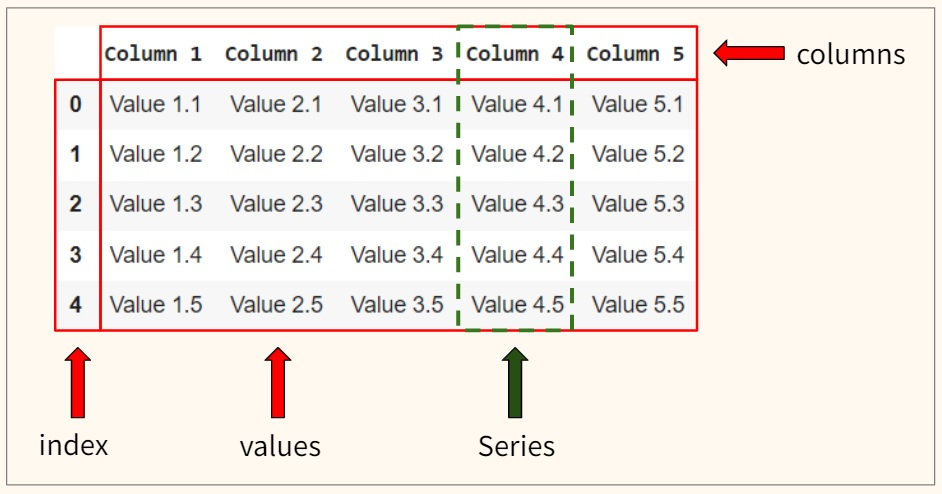
<center>Рис.1. Структура объекта DataFrame</center>

Для понимания предлагаемого далее учебного материала необходимо повторить раздел "Виды данных" из лекции 1 (презентация лекции - в разделе "Лекционный материал", видеозапись лекции - в разделе "Введение в анализ данных" в материалах данного курса).

### Подключение инструментария

Библиотеку **Pandas** (как и другие библиотеки) надо предварительно подключить. В программном коде для этой библиотеки традиционно используется псевдоним **pd**.
Для работы понадобится также библиотека **NumPy**.


In [1]:
import pandas as pd
import numpy as np

## <center> 1. Типы данных Pandas

Обычно под типами данных понимают внутреннее представление, которое описывает некоторое множество данных, определяемое двумя критериями:
- какие значения могут принимать переменные данного типа,
- какие операции могут выполняться над переменными данного типа.

**Напоминание из лекции**: в анализе данных базовыми являются два основных вида данных: ***категориальные*** и ***числовые (количественные)*** данные.
- **Категориальные данные** - нечисловая информация: пол, религия, семейное положение, уровень образования и т. д.
- **Числовые данные** - результат измерения или подсчета: рост, вес, возраст, зарплата, количество детей и т. д.

<u>Основное отличие</u> числовых данных от категориальных: с числовыми данными можно выполнять арифметические операции, причем результат этих операций имеет смысл. Например:
*  *Стипендия (руб.)* - это числовая величина; если умножить её значение на 6, то получим сумму стипендии за шесть месяцев;
*  *Название вуза* - категориальная величина, невозможно выполнить с ней математические операции (нельзя название "ТюмГУ" разделить на 17 и т. п.);
*  *Номер аудитории* в учебном корпусе является категориальной величиной, хотя и выглядит, как число (205, 208, 411 и т. п.); теоретически, эти значения можно умножить, например на 5, но полученный <u>результат не имеет смысла</u>.
    
Каждый из этих двух базовых видов может быть разбит на более мелкие подвиды (дискретные, непрерывные, бинарные, порядковые, ... ) - см. материалы лекции 1. Принадлежность данных к тому или иному виду/подвиду определяет набор допустимых для этих данных методов обработки - это очень важно учитывать на всех этапах обработки и анализа данных!


В языках программирования существует понятие типов данных, при этом к указанным выше двум критериям (какие данные представлены в данном типе и какие операции над данными допустимы) добавляется ещё один:
- как организовано хранение данных в памяти.

В таблице ниже описаны 4 основных типа данных Pandas и соответствующие им типы данных Python и NumPy.
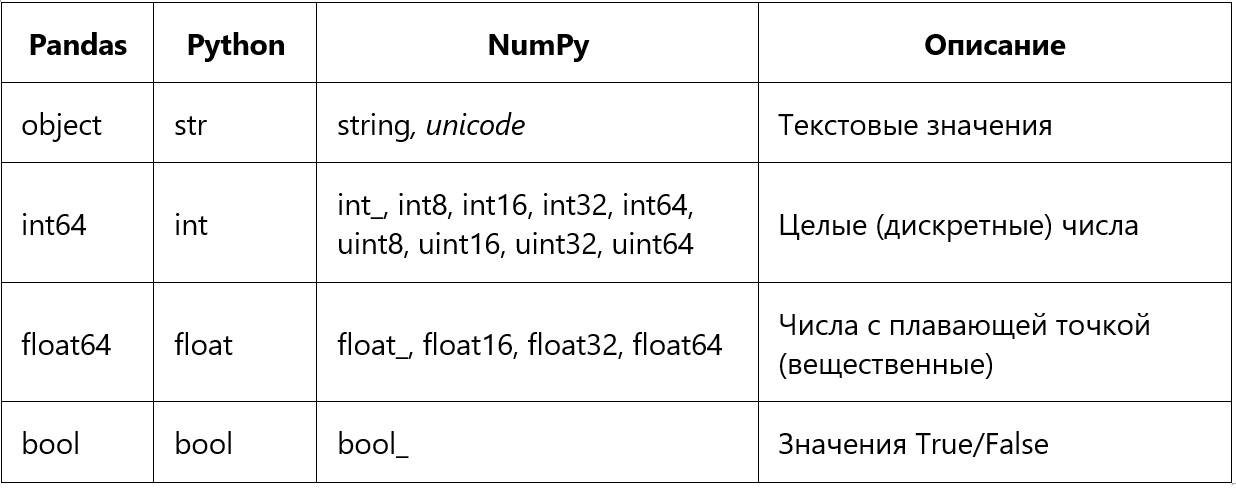
<center>Рис.2. Таблица типов данных Pandas</center>

Тип <code>object</code> обычно представляет категориальные типы, тип <code>int64</code> - числовой дискретный, тип <code>float64</code> - числовой непрерывный, тип <code>bool</code> - логический (бинарный).

Кроме указанных типов в Pandas имеется тип данных <code>datetime64</code>, который хранит значения даты и времени.

## <center> 2. Структура Series

Подробнее о структуре Series можно прочитать [здесь](https://docs-python.ru/packages/modul-pandas-analiz-dannykh-python/obekt-series/).


### Создание Series

Есть несколько способов создать объект **Series**. Обычно такой объект создается из одномерного набора данных.

#### Создание серии из списка

**Пример 1**.

Создание **Series** из списка названий рассмотренных в этом курсе (на данный момент) библиотек Python:

In [2]:
biblio = ['NumPy','SciPy', 'Matplotlib', 'Pandas']
bib_names = pd.Series(biblio)
print(bib_names)

0         NumPy
1         SciPy
2    Matplotlib
3        Pandas
dtype: object


Обратите внимание: список имён библиотек по умолчанию проиндексирован целыми числами, начиная с 0.

Атрибут **dtype** указывает тип данных, содержащихся в данной серии. По умолчанию в библиотеке Pandas для хранения строк используется тип **object**.

#### Cоздание серии с произвольными индексами


**Пример 2**.

Создание **Series** из списка названий библиотек Python с осмысленными значениями индексов (год создания соответствующей библиотеки):

In [3]:
bib_names = pd.Series(['NumPy','SciPy','Matplotlib', 'Pandas'], index=[1995,2001,2003,2008])
print(bib_names)

1995         NumPy
2001         SciPy
2003    Matplotlib
2008        Pandas
dtype: object


#### Cоздание именованной серии случайных чисел

**Пример 3**.


In [4]:
rnd = pd.Series(np.random.randn(4), name='randoms')
rnd

0    0.948674
1   -1.908590
2   -1.248178
3    0.332865
Name: randoms, dtype: float64

#### Cоздание серии из нескольких списков

**Пример 4**.


In [5]:
l = [[1, 2]]
m=[['+','-']]
s = pd.Series(l*2+m*3)
s

0    [1, 2]
1    [1, 2]
2    [+, -]
3    [+, -]
4    [+, -]
dtype: object

Создана серия из двух элементов списка **l** и трёх элементов списка **m**.

#### Cоздание серии из словаря

**Пример 5**.


In [6]:
Simps = pd.Series({'Homer':  'Dad',
                   'Marge':  'Mom',
                   'Bart':   'Son',
                   'Lisa':   'Daughter',
                   'Maggie': 'Daughter'}, name='Simpsons')
Simps

Homer          Dad
Marge          Mom
Bart           Son
Lisa      Daughter
Maggie    Daughter
Name: Simpsons, dtype: object

В созданной серии **Simpsons** ключи словаря (имена персонажей) стали индексами, а значения ключей (роли членов семьи) - значениями серии.

#### Cоздание серии последовательных чисел (из массива)

**Пример 6**.


In [7]:
nums = pd.Series(np.arange(11,33,3))
nums

0    11
1    14
2    17
3    20
4    23
5    26
6    29
7    32
dtype: int64

Создана серия целых чисел от 11 до 33 с шагом 3.

### Доступ к данным серии
К элементам серии можно обращаться как к элементам массива:

 <имя серии>[<индекс>]

In [8]:
print(bib_names)
print("\n","В 2001 году создана библиотека ", bib_names[2001])

1995         NumPy
2001         SciPy
2003    Matplotlib
2008        Pandas
dtype: object

 В 2001 году создана библиотека  SciPy


В качестве альтернативы можно использовать свойство **loc** объекта Series:

In [9]:
print(bib_names.loc[2003])

Matplotlib


К элементу серии также можно обращаться по его порядковому номеру (свойство **iloc**):

In [10]:
print(bib_names.iloc[3])

Pandas


Обратите внимание на отличие индекса (**loc**) элемента серии от его порядкового номера (**iloc**).

## <center> 3. Структура DataFrame

**DataFrame** — это двумерная маркированная структура данных, столбцы которой могут содержать значения разных типов. DataFrame можно рассматривать как контейнер для объектов Series. Он похож на словарь, где ключи — названия столбцов, а значения ключей — серии.

С другой стороны, DataFrame можно рассматривать как набор однотипных строк, имеющих индексы.

Объект  DataFrame будем также называть **фреймом данных** или просто **фреймом**.

Подробнее о структуре DataFrame можно прочитать [здесь](https://docs-python.ru/packages/modul-pandas-analiz-dannykh-python/obekt-dataframe/).

### Создание DataFrame

#### Cоздание объекта DataFrame из двумерного списка

Самое простое - создать DataFrame из двумерной прямоугольной таблицы - списка списков.
Каждый элемент внешнего списка представляет строку фрейма данных, элемент внутреннего списка - отдельный элемент строки фрейма.

**Пример 7**.

In [11]:
df = pd.DataFrame([[10, 11], [22, 33], [44, 55]])
df

,0,1
0,10,11
1,22,33
2,44,55


Получен DataFrame, **состоящий из двух серий (двух столбцов)**, в каждой из которых по 3 элемента:
* индексы элементов каждой серии по умолчанию 0, 1 и 2; они записаны слева от каждой строки с данными;
* при создании фрейма имена столбцов заданы не были, поэтому столбцы также обозначены порядковыми номерами (начиная с нуля).

С другой стороны, можно сказать, что получен DataFrame, **состоящий из трёх записей (трёх строк)**, в каждой из которых по 2 элемента.


#### Определение имен столбцов

**Пример 8**.

Определим названия столбцов фрейма, созданного а примере 7: зададим столбцам имена **А** и **В**.


In [12]:
df.columns = ['A', 'B']
df

,A,B
0,10,11
1,22,33
2,44,55


#### Cоздание объекта DataFrame из словаря.
Фрейм данных можно создать на основе словаря (dict) из готовых серий.

**Пример 9**.

Сначала создадим серии s1 и s2, содержащие по три элемента (в будущем фрейме будет три строки).

Потом создадим фрейм из этих двух серий, объединённых в один словарь; ключи словаря определим как 'S1' и 'S2' соответственно. Эти ключи станут именами столбцов фрейма.

In [13]:
s1 = pd.Series([11,22,33])                 # создание серии s1
s2 = pd.Series(['one','two','three'])      # создание серии s2

df = pd.DataFrame({'S1': s1,               # создание DataFrame из словаря с ключами 'S1' и 'S2' и значениями - элементами серий s1 и s2
                   'S2': s2})
df

,S1,S2
0,11,one
1,22,two
2,33,three


**Пример 10**.

Выполните код в ячейке ниже (использованы объекты Series, созданные в предыдущих примерах: **bib_names** и **rnd**).

Постарайтесь объяснить полученный результат.

In [14]:
df_1 = pd.DataFrame({'col_1': bib_names,
                   'col_2': rnd})
df_1

,col_1,col_2
0,NaN,0.948674
1,NaN,-1.908590
2,NaN,-1.248178
3,NaN,0.332865
1995,NumPy,NaN
2001,SciPy,NaN
2003,Matplotlib,NaN
2008,Pandas,NaN


Ответ: причина появления NaN (отсутствующих значений)  в том, что элементы обеих серий имели заданные индексы, причем индексы элементов этих серий <u>разные</u>. Значения серий с разными индексами записываются в <u>разные</u> строки фрейма.
Если бы хотя бы один индекс у пары элементов двух серий совпал, то соответствующие значения разных серий оказались бы в одной строке с этим индексом.

#### Cоздание объекта DataFrame из массива случайных чисел

**Пример 11**.

Создадим фрейм случайных чисел размерности 4х3 с помощью одной команды.

Источником данных в конструкторе объекта класса **DataFrame** является NumPy-массив из 12 чисел, имеющих нормальное  распределение.

Массив (первоначально одномерный) преобразуется к размерности 4х3: 3 серии по 4 элемента (4 строки и 3 столбца в будущем фрейме).

В конструкторе также указаны строковые значения индексов и названия столбцов (серий).

Предварительно зафиксировано, что при каждом запуске будут генерироваться одни и те же наборы случайных чисел (команда <code>np.random.seed(77)</code> ).

In [15]:
np.random.seed(77)
df = pd.DataFrame(np.random.normal(size=12).reshape(4, 3),       # создание массива псевдослучайных чисел и преобразование его размерности
                  index=['ind_1', 'ind_2', 'ind_3', 'ind_4'],    # определение индексов
                  columns=['col_1', 'col_2', 'col_3'])           # определение названий столбцов
df

,col_1,col_2,col_3
ind_1,0.224445,0.661531,-0.579758
ind_2,0.407811,0.466479,-1.974709
ind_3,0.275548,-1.575805,1.568397
ind_4,-0.724795,0.305890,1.163942


## <center> 4. Загрузка и создание файлов данных в Pandas
Если предполагается обрабатывать данные из внешних источников и сохранять полученные результаты для дальнейшей работы с ними, то в программе обязательно будет обращение к файлу с данными.

### CSV - файлы
Pandas поддерживает операции чтения и записи для файлов разного типа: TXT, CSV, Excel 2007+, SQL, HTML, JSON и др.

Многие пользователи считают наиболее удобной работу с файлами формата **.csv**, структура которого соответствует таблице DataFrame, а содержимое можно открыть и изучить в любом текстовом редакторе.


**CSV (Comma-Separated Values)** - это формат файла, используемый для хранения и обмена табличными данными. В CSV-файле данные представлены в виде текста, где каждая запись сохранена в отдельной строке, а значения одной строки разделены запятыми (или другим разделителем).

CSV - один из самых простых и распространенных форматов для обмена табличными данными между различными приложениями.

**Основные характеристики CSV-файлов включают:**

- **Разделение значений**: Значения в строках CSV-файла разделяются определенным символом, который чаще всего является запятой, но также может быть точкой с запятой, пробелом, табуляцией и т. д. Этот символ называется разделителем.
- **Строки данных**: Каждая строка в CSV-файле представляет собой запись данных. Эти строки разделяются символами новой строки (или перевода строки); каждая строка содержит набор значений, разделенных разделителем.
- **Имена cтолбцов**: В CSV-файлах первая строка часто содержит названия столбцов (также через разделитель), что позволяет понять, какие данные хранятся в каждом столбце. Это облегчает создание фрейма данных из содержимого файла.
- **Заголовок файла**: Иногда в CSV-файлах первые строки (перед названиями столбцов) содержат различную описательную информацию о содержимом файла (название датасета, источник данных, права на использование и т.п.). Эта служебная информация не должна включаться во фрейм данных, поэтому такие строки нужно пропустить при чтении данных. Далее будет показано, как это сделать.

#### Размещение файла с данными

В Jupyter Notebook файлы читаются из папки на локальном компьютере. Файл с данными рекомендуется размещать в той же папке, где находится файл блокнота (ipynb-файл) с кодом обращения к CSV-файлу. Тогда при указании в программном коде пути к CSV-файлу достаточно использовать короткий путь (например, "data.csv"). В противном случае нужно будет указывать полный путь к CSV-файлу.

### Чтение CSV - файлов

Для чтения данных из файла используется функция <code>**read_csv**()</code> библиотеки Pandas.

Гибкость применения функции поддерживается наличием у этой функции большого числа параметров, о назначении которых можно прочитать в [документации](https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html).

Применение параметров рассмотрим на примере нескольких часто встречающихся ситуаций.
Эти ситуации проиллюстрируем в ходе импорта данных из файла **stats.csv**, содержащем информацию об имени, поле, возрасте, росте и весе 18 человек. Файл размещен в ресурсах данного занятия на платформе LMS.

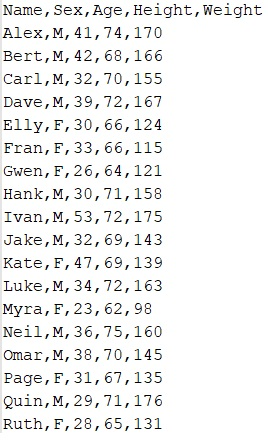
<center>Рис.3. Содержание файла stats.csv</center>

**Пример 12**.

#### Чтение всего содержимого CSV-файла

 Обязательным параметром функции **read_csv()** является строка, содержащая имя загружаемого файла.

 Чтобы не было путаницы, используем также параметр  <code> sep = ','</code>, который однозначно указывает, что именно запятая разделяет элементы одной строки в указанном файле.

 Импортированные данные сохраняются в DataFrame с именем group.


In [16]:
group = pd.read_csv('stats.csv',  sep = ',')
group

,Name,Sex,Age,Height,Weight
0,Alex,M,41,74,170
1,Bert,M,42,68,166
2,Carl,M,32,70,155
3,Dave,M,39,72,167
4,Elly,F,30,66,124
5,Fran,F,33,66,115
6,Gwen,F,26,64,121
7,Hank,M,30,71,158
8,Ivan,M,53,72,175
9,Jake,M,32,69,143


Если CSV-файл (и, следовательно, созданный при выполнении импорта фрейм) содержит много строк, то может быть удобно вывести только несколько первых и/или последних строк.

In [17]:
group.head(3)  # вывод первых 3 строк

,Name,Sex,Age,Height,Weight
0,Alex,M,41,74,170
1,Bert,M,42,68,166
2,Carl,M,32,70,155


In [18]:
group.tail(3)  # вывод последних 3 строк

,Name,Sex,Age,Height,Weight
15,Page,F,31,67,135
16,Quin,M,29,71,176
17,Ruth,F,28,65,131


По умолчанию методы **head()** и  **tail()** выводят по 5 строк.

#### Чтение определенных столбцов из CSV-файла

Создадим фрейм, в который будут импортированы только имена и возраст членов группы; остальные признаки загружаться не должны.


In [19]:
df_ = pd.read_csv('stats.csv', usecols=['Name', 'Age'])
df_.head()

,Name,Age
0,Alex,41
1,Bert,42
2,Carl,32
3,Dave,39
4,Elly,30


#### Учёт наличия строк заголовка в CSV-файле
Если несколько первых строк CSV-файла содержат служебную информацию (заголовок набора данных, его описание), которая не должна загружаться во фрейм, то соответствующие строки CSV-файла должны быть пропущены при выполнении загрузки данных. Этим можно управлять с помощью параметра  <code> header = ... </code>(указывает, сколько начальных строк нужно пропустить при загрузке).

In [20]:
df_ = pd.read_csv('stats.csv', header= 2)  # первые 2 строки не будут загружены во фрейм
df_.head()

,Bert,M,42,68,166
0,Carl,M,32,70,155
1,Dave,M,39,72,167
2,Elly,F,30,66,124
3,Fran,F,33,66,115
4,Gwen,F,26,64,121


В файле **stats.csv** не было заголовков и другой служебной информации; в соответствии с настройками импорта были пропущены первые две строки: строка с именами столбцов и строка с данными Алекса.

В качестве названий столбцов были взяты данные Берта: по умолчанию первая загружаемая строка используется для формирования названий столбцов.

#### Пропуск строк при чтении CSV-файла
Если некоторые строки из файла с данными следует пропустить при загрузке, то используется параметр <code> skiprows = ... </code>
(указывает список номеров тех строк, которые следует пропустить).

In [21]:
df_ = pd.read_csv('stats.csv', skiprows = [2,5,6])
df_.head()

,Name,Sex,Age,Height,Weight
0,Alex,M,41,74,170
1,Carl,M,32,70,155
2,Dave,M,39,72,167
3,Gwen,F,26,64,121
4,Hank,M,30,71,158


При чтении были пропущены строки с номерами 2, 5 и 6, содержащие данные по Берту, Элли и Франу.

#### Чтение данных из CSV-файла, размещенного на Интернет-ресурсе
Для работы может быть необходимо загружать табличные данные из CSV-файлов, которые хранятся не на локальном компьютере, а на различных Интернет-ресурсах. В этом случае может быть использована та же функция  <code>read_csv()</code>, только вместо адреса файла на локальном диске используется URL-адрес.

Например, для загрузки таблицы с данными о пассажирах печально известного теплохода "Титаник" достаточно выполнить команду:

In [22]:
titanic_df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Сохранение данных из фрейма в CSV-файл
Данная операция выполняется с помощью функции <code>to_csv()</code>  — метода класса DataFrame, который применяется к экземпляру класса - фрейму данных.

Эта функция, как и рассмотренная ранее функция read_csv(), имеет множество параметров.

**Пример 13**.

Создадим фрейм с данными (имя и возраст) трех человек - из списков:

In [23]:
df_ = pd.DataFrame([['Антон', 35], ['Виктор', '41'], ['Светлана', '27']], columns=['Имя', 'Возраст'])
df_

,Имя,Возраст
0,Антон,35
1,Виктор,41
2,Светлана,27


#### Сохранение в CSV-файле копии фрейма
Для сохранения копии фрейма при вызове функции <code>to_csv()</code> достаточно указать только один параметр - имя создаваемого файла.

In [24]:
df_.to_csv('Trio.csv')

При использовании короткого пути файл с указанным именем будет создан в той же папке, в которой находится файл блокнота (ipynb-файл) с командой на создание CSV-файла.

Созданный файл будет иметь такое содержимое:
> ,Имя,Возраст

> 0,Антон,35

> 1,Виктор,41

> 2,Светлана,27


Загрузка всех данных из этого файла сформирует фрейм, отличный от созданного ранее: в нём будут три колонки, а не две. Причина: при создании CSV-файла с настройками по умолчанию в качестве первого столбца были сохранены индексы строк исходного фрейма.

In [25]:
df_= pd.read_csv('Trio.csv')
df_

,Unnamed: 0,Имя,Возраст
0,0,Антон,35
1,1,Виктор,41
2,2,Светлана,27


#### Сохранение данных из фрейма в CSV-файл без индексов
Управлять сохранением индексов строк фрейма в CSV-файл можно с помощью параметра **index** (по умолчанию имеет значение True).

In [26]:
df_ = pd.DataFrame([['Антон', 35], ['Виктор', '41'], ['Светлана', '27']], columns=['Имя', 'Возраст'])
df_.to_csv('Trio.csv', index=False)    # сохранение без индексов

Созданный файл будет иметь уже адекватное содержимое:

> Имя,Возраст

> Антон,35

> Виктор,41

> Светлана,27


#### Выбор столбцов и символа разделителя при сохранении в CSV-файл
При сохранении фрейма данных в файл можно указать новые имена столбцов и выбрать символ разделителя элементов строки (вместо запятой, которая определена по умолчанию).

In [27]:
df_ = pd.DataFrame([['Антон', 35], ['Виктор', '41'], ['Светлана', '27']], columns=['Имя', 'Возраст'])
df_.to_csv('Trio.csv', index=False, sep=';', header=['Name', 'Age'])    # определение разделителя и новых названий столбцов

Созданный файл будет иметь такое содержимое:

> Name;Age

> Антон;35

> Виктор;41

> Светлана;27


**Упражнение**.
Выполните все действия, описанные в примере 13, и убедитесь в правильности всех представленных результатов.

## <center> 5. Просмотр и изменение свойств структур данных Pandas

Управление свойствами структур данных Pandas рассмотрим на примере созданных ранее объектов: **Simps** и **nums** (серии), а также **group** (фрейм данных).

Выведем эти объекты (для напоминания).

In [28]:
Simps

Homer          Dad
Marge          Mom
Bart           Son
Lisa      Daughter
Maggie    Daughter
Name: Simpsons, dtype: object

In [29]:
nums

0    11
1    14
2    17
3    20
4    23
5    26
6    29
7    32
dtype: int64

In [30]:
group

,Name,Sex,Age,Height,Weight
0,Alex,M,41,74,170
1,Bert,M,42,68,166
2,Carl,M,32,70,155
3,Dave,M,39,72,167
4,Elly,F,30,66,124
5,Fran,F,33,66,115
6,Gwen,F,26,64,121
7,Hank,M,30,71,158
8,Ivan,M,53,72,175
9,Jake,M,32,69,143


Обратите внимание: для вывода данных из фреймов в примерах выше не использовался print().

Команду print() можно использовать для вывода фрейма, но делать это не рекомендуется: при выводе больших фреймов 
отображенные данные будут плохо читаемы.

Для "красивого" вывода данных фрейма рекомендуется использовать метод **display()**:

In [31]:
display(group)

,Name,Sex,Age,Height,Weight
0,Alex,M,41,74,170
1,Bert,M,42,68,166
2,Carl,M,32,70,155
3,Dave,M,39,72,167
4,Elly,F,30,66,124
5,Fran,F,33,66,115
6,Gwen,F,26,64,121
7,Hank,M,30,71,158
8,Ivan,M,53,72,175
9,Jake,M,32,69,143


Можно управлять параметрами вывода (максимальным количеством отображаемых строк и столбцов и др.):

[Описание настроек вывода](https://pandas.pydata.org/pandas-docs/stable/user_guide/options.html)

### Просмотр типов данных элементов структуры
*  Для вывода типа данных отдельных элементов серии используется атрибут серии <code>.dtype</code> (применяется к серии);

*  для вывода типов данных отдельных элементов столбцов фрейма используется атрибут фрейма <code>.dtypes</code> (применяется к фрейму).

Обратите внимание: названия атрибутов серии и фрейма похожи, но не одинаковы. Подумайте, почему.

In [32]:
print(Simps.dtype)   # вывод типа данных элементов серии Simps

object


In [33]:
print(nums.dtype)    # вывод типа данных элементов серии nums

int64


In [34]:
group.dtypes   # вывод типов данных элементов столбцов фрейма group

Name      object
Sex       object
Age        int64
Height     int64
Weight     int64
dtype: object

Как видим, в **Simps** хранятся строки, в **nums** - целые числа, а в **group** хранятся значения пяти серий - пять столбцов, два из которых строкового типа (object), т.е. категориальные данные, и три - целого (int64), т.е. дискретные количественные данные.

### Вывод размеров структуры
Под размером конкретного объекта (структуры данных) можно понимать разные размерные характеристики, поэтому у объектов  Pandas для работы с каждой из характеристик имеются свои инструменты:
- **len(<объект>)** - функция, которая возвращает число элементов серии/число строк во фрейме;
- **<объект>.size** - атрибут объекта - число простых данных (отдельных элементов) объекта;
- **<объект>.shape** - атрибут объекта - размерность структуры: (<число строк>,<число столбцов>).

Обратите внимание:
*  **len()** - это функция, аргументом которой является объект (структура данных);
*  **size** и **shape** - атрибуты объекта (вызываются через точку после имени объекта).

Вывод характеристик серии:

In [35]:
print('Число элементов      :', len(Simps))
print('Число простых данных :', Simps.size)
print('Размерность          :', Simps.shape)

Число элементов      : 5
Число простых данных : 5
Размерность          : (5,)


В серии **Simps** 5 элементов, 5 экземпляров данных (имён) и она выглядит как столбик из 5 значений.

Вывод характеристик DataFrame:

In [36]:
print('Число элементов      :', len(group))
print('Число простых данных :', group.size)
print('Размерность          :', group.shape)

Число элементов      : 18
Число простых данных : 90
Размерность          : (18, 5)


В таблице **group** 18 элементов-строк,  90 экземпляров данных (имён, чисел), расположенных в 18 строках и 5 колонках.

### Количество уникальных элементов

Вычисляется с помощью функции **nunique()**, которая может применяться и к сериям, и к фреймам.

In [37]:
Simps.nunique()

4

In [38]:
group.nunique()

Name      18
Sex        2
Age       16
Height    12
Weight    18
dtype: int64

В серии **Simps** 4 уникальных значения (одно из которых повторяется дважды).

Фрейм **group** содержит 18 уникальных имён (18 уникальных элементов столбца  Name), 2 варианта пола, 16 различных значений возраста, ...

### Изменение значений отдельных столбцов фрейма
Если в массиве для однотипного изменения значений всего столбца надо в цикле перебрать элементы столбца, то во фрейме преобразование всего столбца можно выполнить одной командой. Для этого: к отдельному столбцу фрейма можно обратиться, как к серии, и применить к серии требуемую операцию; изменённую серию записать вместо преобразуемого столбца.

**Пример 14**.

Переведём значения роста и веса в дюймах и фунтах, сохраненные во фрейме **group**, в более привычные нам сантиметры и килограммы.

In [39]:
# Вывод исходных данных (для напоминания)
group.head()

,Name,Sex,Age,Height,Weight
0,Alex,M,41,74,170
1,Bert,M,42,68,166
2,Carl,M,32,70,155
3,Dave,M,39,72,167
4,Elly,F,30,66,124


In [40]:
group['Height'] = group['Height']*2.54
group['Weight'] = group['Weight']*0.4536
group.head()

,Name,Sex,Age,Height,Weight
0,Alex,M,41,187.96,77.1120
1,Bert,M,42,172.72,75.2976
2,Carl,M,32,177.80,70.3080
3,Dave,M,39,182.88,75.7512
4,Elly,F,30,167.64,56.2464


### Изменение типа данных для отдельных столбцов фрейма

Такое преобразование реализует метод **astype()** - применяется к серии или фрейму. В качестве аргумента нужно указать обозначение нового типа данных.

**Пример 14** (продолжение).

После перевода в сантиметры и килограммы значения роста и веса во фрейме **group** стали вещественными с несколькими знаками после запятой. Такая точность для этих данных может быть излишней; приведём значения роста и веса к целому типу.


In [41]:
group['Weight'] = group['Weight'].astype('int')
group['Height'] = group['Height'].astype('int')
group.head()

,Name,Sex,Age,Height,Weight
0,Alex,M,41,187,77
1,Bert,M,42,172,75
2,Carl,M,32,177,70
3,Dave,M,39,182,75
4,Elly,F,30,167,56


### Наличие пустых ячеек
Некоторые данные во фрейме могут отсутствовать. При отображении данных фрейма это принято обозначать NaN (not a number); в программном коде в новых версиях программы используется nan.

**Пример 15**.

Сделаем значение веса у Карла во фрейме **group** неизвестным.

In [42]:
group.loc[2,'Weight'] = np.nan;
group.head()

,Name,Sex,Age,Height,Weight
0,Alex,M,41,187,77.0
1,Bert,M,42,172,75.0
2,Carl,M,32,177,NaN
3,Dave,M,39,182,75.0
4,Elly,F,30,167,56.0


Один из способов проверить наличие NaN в DataFrame — использовать функцию **isnull()**.

Она возвращает другой DataFrame, где все значения - булевы; указывающеют, является ли соответствующее значение в исходном DataFrame NaN.

In [43]:
group.isnull().head()

,Name,Sex,Age,Height,Weight
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,True
3,False,False,False,False,False
4,False,False,False,False,False


Чтобы узнать, имеется ли хотя бы одно значение NaN в DataFrame, можно использовать функцию **any()**, которая возвращает True, если хотя бы одно значение в DataFrame является NaN.

In [44]:
group.isnull().any()

Name      False
Sex       False
Age       False
Height    False
Weight     True
dtype: bool

Для подсчета количества NaN во фрейме можно использовать агрегатную функцию **sum()**.

In [45]:
group.isnull().sum()

Name      0
Sex       0
Age       0
Height    0
Weight    1
dtype: int64

## <center> 6. Работа с индексами и значениями

### Индексы и значения Series
В одномерном наборе данных у каждого элемента есть индекс и значение. Так, математическая запись х<sub>5</sub> = 12 означает, что у 5-го элемента одномерного набора x (элемента с индексом 5) значение равно 12.

Pandas позволяет получить список всех индексов серии и список значений всех элементов.

In [46]:
Simps.index       # вывод списка индексов серии Simps

Index(['Homer', 'Marge', 'Bart', 'Lisa', 'Maggie'], dtype='object')

In [47]:
Simps.values      # вывод списка значений серии Simps

array(['Dad', 'Mom', 'Son', 'Daughter', 'Daughter'], dtype=object)

Можно получить значение элемента серии по его индексу:

In [48]:
Simps['Homer']

'Dad'

Аналогично можно изменить значение элемента серии с конкретным индексом.

Например, изменение семейного статуса Гомера:

In [49]:
Simps['Homer']='SuperDad'
Simps

Homer     SuperDad
Marge          Mom
Bart           Son
Lisa      Daughter
Maggie    Daughter
Name: Simpsons, dtype: object

### Индексы и значения DataFrame
Фрейм - двумерный набор, у каждого его элемента имеется две координаты: номер строки и номер столбца.

Аналогия с математической записью:  Y<sub>5,2</sub> = 7.8 означает, что элемент двумерного набора Y, расположенный на пересечении 5-й строки и 2-го столбца равен 7.8.

Pandas позволяет узнать индексы всех строк фрейма, список названий всех столбцов и таблицу значений всех элементов.

In [50]:
group.index

RangeIndex(start=0, stop=18, step=1)

Действительно, у строк датафрейма **group** индексы - это порядковые номера от 0 до 17 с шагом 1.

In [51]:
group.columns

Index(['Name', 'Sex', 'Age', 'Height', 'Weight'], dtype='object')

Во фрейме **group** 5 столбцов с указанными названиями.

In [52]:
group.values

array([['Alex', 'M', 41, 187, 77.0],
       ['Bert', 'M', 42, 172, 75.0],
       ['Carl', 'M', 32, 177, nan],
       ['Dave', 'M', 39, 182, 75.0],
       ['Elly', 'F', 30, 167, 56.0],
       ['Fran', 'F', 33, 167, 52.0],
       ['Gwen', 'F', 26, 162, 54.0],
       ['Hank', 'M', 30, 180, 71.0],
       ['Ivan', 'M', 53, 182, 79.0],
       ['Jake', 'M', 32, 175, 64.0],
       ['Kate', 'F', 47, 175, 63.0],
       ['Luke', 'M', 34, 182, 73.0],
       ['Myra', 'F', 23, 157, 44.0],
       ['Neil', 'M', 36, 190, 72.0],
       ['Omar', 'M', 38, 177, 65.0],
       ['Page', 'F', 31, 170, 61.0],
       ['Quin', 'M', 29, 180, 79.0],
       ['Ruth', 'F', 28, 165, 59.0]], dtype=object)

Данные, хранящиеся во фрейме **group**, представляют собой двумерную таблицу из 18 строк по 5 элементов в каждой строке.

### Доступ к отдельным элементам фрейма
Для получения значения элемента фрейма, расположенного на пересечении строки с заданным индексом и столбца c заданным именем можно использовать свойство <b>.loc</b> этого фрейма.

Например, получить имя 4-го по порядку человека во фрейме **group** можно так:

In [53]:
group.loc[4]['Name']

'Elly'

или так:

In [54]:
group.loc[4, 'Name']

'Elly'

Есть и другие способы.

Например, с помощью свойства <b>.at</b>:

In [55]:
group.at[4,'Name']

'Elly'

Или, как значение указанного столбца (т. е. серии) с указанным индексом:

In [56]:
group['Name'].values[4]

'Elly'

Если вместо названий столбцов удобнее использовать их номера (например, при совместной обработке нескольких столбцов большого фрейма), то для обращения к элементу фрейма можно использовать свойство **.iloc** (вместо **.loc**):

In [57]:
group.iloc[4, 0]

'Elly'

Если в серии или фрейме используются строковые индексы, то обратиться к элементу строки можно и по строковому индексу  (с помощью **.loc**), и по порядковому номеру строки (с помощью **.iloc**):

In [58]:
print("Доступ к строке по строковому индексу : ", Simps.loc['Bart'])
print("Доступ к строке по числовому индексу  : ", Simps.iloc[2])

Доступ к строке по строковому индексу :  Son
Доступ к строке по числовому индексу  :  Son


Для изменения значения отдельных элементов фрейма при обращении к элементам лучше использовать свойство <b>.at</b>.

Например, увеличим возраст второго студента из фрейма **group** на 1 год:

In [59]:
print("Было   : ", group.loc[2,'Age'])
group.at[2,'Age'] = group.at[2,'Age'] + 1
print("Стало  : ", group.loc[2,'Age'])


Было   :  32
Стало  :  33


Попробуйте разобраться, как в примере ниже был использовано свойство <b>.loc</b>:

In [60]:
group.loc[group['Name'] == 'Carl', ['Age']] = 18
group.head()

,Name,Sex,Age,Height,Weight
0,Alex,M,41,187,77.0
1,Bert,M,42,172,75.0
2,Carl,M,18,177,NaN
3,Dave,M,39,182,75.0
4,Elly,F,30,167,56.0


## <center> 7. Получение срезов и фильтрация строк

### Выделение отдельных столбцов

Отдельные столбцы фрейма можно сохранить в виде серии.

Например, сохраним столбец с именами из фрейма **group** как серию **group_names**:

In [61]:
group_names = group['Name']
group_names

0     Alex
1     Bert
2     Carl
3     Dave
4     Elly
5     Fran
6     Gwen
7     Hank
8     Ivan
9     Jake
10    Kate
11    Luke
12    Myra
13    Neil
14    Omar
15    Page
16    Quin
17    Ruth
Name: Name, dtype: object

Для указания нужного столбца может быть использована как *скобочная* нотация:

<code>column_data = df['column_name']</code>

(показана в предыдущем примере), так и *точечная* нотация:

<code>column_data = df.column_name</code>

Например, сохранение столбца с именами (предыдущий пример) может быть выполнено так:

In [62]:
group_names = group.Name
group_names

0     Alex
1     Bert
2     Carl
3     Dave
4     Elly
5     Fran
6     Gwen
7     Hank
8     Ivan
9     Jake
10    Kate
11    Luke
12    Myra
13    Neil
14    Omar
15    Page
16    Quin
17    Ruth
Name: Name, dtype: object

Несколько столбцов существующего фрейма можно сохранить как новый DataFrame.

Например, сохраним в новом фрейме столбцы фрейма **group** с информацией об имени, возрасте и росте:

In [63]:
group_NameAgeHei = group[['Name','Age','Height']]
group_NameAgeHei

,Name,Age,Height
0,Alex,41,187
1,Bert,42,172
2,Carl,18,177
3,Dave,39,182
4,Elly,30,167
5,Fran,33,167
6,Gwen,26,162
7,Hank,30,180
8,Ivan,53,182
9,Jake,32,175


Для совместной работы с несколькими идущими подряд столбцами фрейма удобно использовать номера, а не названия столбцов.

In [64]:
# Сохранение в отдельном фрейме столбцов фрейма group с номерами от 1 до 4 (4 включается, 5 - нет)

group_part = group[group.columns[1:5]]
group_part

,Sex,Age,Height,Weight
0,M,41,187,77.0
1,M,42,172,75.0
2,M,18,177,NaN
3,M,39,182,75.0
4,F,30,167,56.0
5,F,33,167,52.0
6,F,26,162,54.0
7,M,30,180,71.0
8,M,53,182,79.0
9,M,32,175,64.0


### Создание срезов

***Срез*** — это часть фрейма, ограниченная указанными индексами строк и/или названиями (номерами) столбцов.

Создать срез существующей таблицы можно с помощью свойства <b>.loc</b> или <b>.iloc</b> исходного фрейма.

In [65]:
group_part = group.loc[0:3, 'Name':'Age']
group_part

,Name,Sex,Age
0,Alex,M,41
1,Bert,M,42
2,Carl,M,18
3,Dave,M,39


In [66]:
group_part = group.iloc[0:3, 0:3]
group_part

,Name,Sex,Age
0,Alex,M,41
1,Bert,M,42
2,Carl,M,18


### Переименование и перестановка столбцов
Для облегчения анализа и повышения читаемости кода может возникнуть необходимость переименования столбцов фрейма или изменения порядка их следования.

Для переименования отдельного столбца используется метод **rename()** (применяется к фрейму).

Например, переименуем столбец 'Age' фрейма **group** в 'Years':

In [67]:
df1 = group.rename(columns={'Age':'Years'})
df1.head(3)

,Name,Sex,Years,Height,Weight
0,Alex,M,41,187,77.0
1,Bert,M,42,172,75.0
2,Carl,M,18,177,NaN


Для изменения порядка следования столбцов нужно определить список названий столбцов в требуемом порядке и сформированть новый фрейм с именами столбцов в указанном порядке.

Например:

In [68]:
new_cols = ['Name', 'Age', 'Height', 'Weight', 'Sex']
df2 = group[new_cols]
df2

,Name,Age,Height,Weight,Sex
0,Alex,41,187,77.0,M
1,Bert,42,172,75.0,M
2,Carl,18,177,NaN,M
3,Dave,39,182,75.0,M
4,Elly,30,167,56.0,F
5,Fran,33,167,52.0,F
6,Gwen,26,162,54.0,F
7,Hank,30,180,71.0,M
8,Ivan,53,182,79.0,M
9,Jake,32,175,64.0,M


### Фильтрация строк

Фильтрация — это отбор из исходного набора данных только тех элементов, которые удовлетворяют заданным условиям.

#### Выбор строк фрейма данных на основе значения определенного столбца с помощью операций сравнения

Например, выберем из фрейма **group** те строки, которые содержат информацию о женщинах, и сохраним отобранные строки в новом фрейме **df1**:

In [69]:
df1 = group[group['Sex']=='F']
df1

,Name,Sex,Age,Height,Weight
4,Elly,F,30,167,56.0
5,Fran,F,33,167,52.0
6,Gwen,F,26,162,54.0
10,Kate,F,47,175,63.0
12,Myra,F,23,157,44.0
15,Page,F,31,170,61.0
17,Ruth,F,28,165,59.0


<u>Пояснение</u>:  


> group['Sex'] == 'F'  —  условие отбора строк;


> group[group['Sex'] == 'F']  —  строки из **group**, которые удовлетворяют условию отбора

Еще пример: выберем те строки из **group**, которые соответствуют лицам не старше 30 лет:

In [70]:
df2 = group[group['Age'] <= 30]
df2

,Name,Sex,Age,Height,Weight
2,Carl,M,18,177,NaN
4,Elly,F,30,167,56.0
6,Gwen,F,26,162,54.0
7,Hank,M,30,180,71.0
12,Myra,F,23,157,44.0
16,Quin,M,29,180,79.0
17,Ruth,F,28,165,59.0


Теперь выберем те строки из **group**, которые содержат информацию о лицах с именами Bert, Carl и Ruth:

In [71]:
names = ['Bert','Carl','Ruth']
df3 = group[group['Name'].isin(names)]
df3

,Name,Sex,Age,Height,Weight
1,Bert,M,42,172,75.0
2,Carl,M,18,177,NaN
17,Ruth,F,28,165,59.0


Для формирования сложных условий (с использованием более одной операции сравнения) дополнительно применяются логические операции:
*   "&" (AND - одновременная истинность простых условий - логическое умножение),
*   "|" (OR - истинность хотя бы одного из простых условий - логическое сложение).

Например, пусть требуется отобрать из фрейма **group** данные о мужчинах, рост которых меньше 180 см. Это условие может быть разделено на два простых условия:
* group['Sex'] == 'M' (принадлежность к мужчинам),
* group['Height'] < 180 (ограничение по росту).

Для реализации отбора нужно одновременное выполнение обоих простых условий, поэтому отбор нужных строк будет выглядеть так:

In [72]:
df4 = group[(group['Sex'] == 'M') & (group['Height'] < 180)]
df4

,Name,Sex,Age,Height,Weight
1,Bert,M,42,172,75.0
2,Carl,M,18,177,NaN
9,Jake,M,32,175,64.0
14,Omar,M,38,177,65.0


Если требуется не выбрать, а наоборот, исключить из набора данных строки, удовлетворяющие некоторому условию (равнозначно: отобрать строки, НЕ удовлетворяющие условию), то это можно сделать, используя символ "~" (обозначение логического отрицания в Pandas).

Например, формирование фрейма df2, содержащего информацию о лицах не старше 30 лет, можно реализовать через отрицание (равнозначно исключению информации о лицах старше 30 лет):

In [73]:
df2 = group[~(group['Age'] > 30)]
df2

,Name,Sex,Age,Height,Weight
2,Carl,M,18,177,NaN
4,Elly,F,30,167,56.0
6,Gwen,F,26,162,54.0
7,Hank,M,30,180,71.0
12,Myra,F,23,157,44.0
16,Quin,M,29,180,79.0
17,Ruth,F,28,165,59.0


#### Метод .query()

Метод **.query()** позволяет задавать условие фильтрации в более краткой нотации.

Повторим выбор данных о мужчинах ниже 180 см (обратите внимание на разные кавычки для строк!):

In [74]:
df44 = group.query("(Sex == 'M') & (Height < 180)")
df44

,Name,Sex,Age,Height,Weight
1,Bert,M,42,172,75.0
2,Carl,M,18,177,NaN
9,Jake,M,32,175,64.0
14,Omar,M,38,177,65.0


#### Методы .nlargest() и  .nsmallest()

Позволяют находить строки с наибольшими (наименьшими) значениями в указанном столбце:


In [75]:
df6 = group.nlargest(3,'Age')
df6

,Name,Sex,Age,Height,Weight
8,Ivan,M,53,182,79.0
10,Kate,F,47,175,63.0
1,Bert,M,42,172,75.0


Первый параметр, равный 3, указывает, что нужно выбрать трёх людей, старших по возрасту.

## <center> 8. Операции над DataFrame

### Копирование фрейма

Если DataFrame предполагается изменять в процессе работы с ним, а первоначальный вариант таблицы также может понадобиться в дальнейшем, то разумно сделать копию первоначального фрейма.

Сохраним таблицу **group** под именем **group_base** (первоначальный вариант). А фрейм **group** будем изменять в процессе работы с ним.

In [76]:
group_base = group.copy()
group_base

,Name,Sex,Age,Height,Weight
0,Alex,M,41,187,77.0
1,Bert,M,42,172,75.0
2,Carl,M,18,177,NaN
3,Dave,M,39,182,75.0
4,Elly,F,30,167,56.0
5,Fran,F,33,167,52.0
6,Gwen,F,26,162,54.0
7,Hank,M,30,180,71.0
8,Ivan,M,53,182,79.0
9,Jake,M,32,175,64.0


**Обратите внимание!**

Простое присваивание <code>group_base = group</code> создаёт не копию текущей таблицы, а сохраняет ссылку на ТУ ЖЕ таблицу в другой переменной.

Покажем это на примере:

In [77]:
record = {
 'Name' : ['Anit', 'Swil', 'Aisha'],
 'Age'  : [22, 18, 25]}
df0 = pd.DataFrame(record)         # создание модельного фрейма df0 из словаря record
print("Base Dataframe :\n", df0)   # вывод первоначального фрема

df1 = df0.copy()                   # создание фрейма df1 - копии фрейма df0
df2 = df0                          # создание новой переменной df2 - ссылки на исходный фрейм df0

df1.loc[0,'Age']=55                # изменение одного значения в df1
df2.loc[1,'Age']=66                # изменение одного значения в df2

print("Base Dataframe :\n", df0)   # вывод исходного фрейма df0

Base Dataframe :
     Name  Age
0   Anit   22
1   Swil   18
2  Aisha   25
Base Dataframe :
     Name  Age
0   Anit   22
1   Swil   66
2  Aisha   25


Обратите внимание: изменение копии **df1** не испортило **df0**, а изменение переменной **df2** (ссылки на **df0**) привело к изменению и самого **df0**.

### Удаление элементов фрейма

Удаление элементов фрейма данных может быть выполнено с помощью метода **.drop()** этого датафрейма.

Метод можно применять с использованием индексов строк и названий столбцов.

#### Удаление строк по их индексу

Удалим из фрейма **group** строки с номерами 0, 2, 16.

In [78]:
group.drop([0, 2, 16], inplace = True)
group

,Name,Sex,Age,Height,Weight
1,Bert,M,42,172,75.0
3,Dave,M,39,182,75.0
4,Elly,F,30,167,56.0
5,Fran,F,33,167,52.0
6,Gwen,F,26,162,54.0
7,Hank,M,30,180,71.0
8,Ivan,M,53,182,79.0
9,Jake,M,32,175,64.0
10,Kate,F,47,175,63.0
11,Luke,M,34,182,73.0


Уточнение <code>inplace = True</code> указывает, что измененный фрейм заменит существующий (изменения сохранятся не только в копии, но и в самом фрейме).

#### Удаление столбцов по их названиям

Удалим из фрейма **group** столбцы с ростом и весом

In [79]:
group.drop(['Height','Weight'], axis=1, inplace = True)
group

,Name,Sex,Age
1,Bert,M,42
3,Dave,M,39
4,Elly,F,30
5,Fran,F,33
6,Gwen,F,26
7,Hank,M,30
8,Ivan,M,53
9,Jake,M,32
10,Kate,F,47
11,Luke,M,34


Уточнение <code>axis=1</code> (ось равна 1) указывает, что удаляются столбцы, а не строки (для строк axis=0).

### Сортировка значений в столбцах фрейма
Для сортировки значений в столбцах датафрейма используется метод **.sort_values()**. Этому методу можно передать, в частности, следующие параметры:
- by — по какому столбцу или столбцам вести сортировку,
- inplace — сохранять ли результаты сортировки в исходном фрейме,
- ascending — выполнять сортировку в восходящем (**true** по умолчанию) или нисходящем порядке.

Например: отсортируем данные таблицы **group** по возрасту:

In [80]:
group = group_base.copy()     # восстановление первоначальной таблицы из созданной ранее копии
group.sort_values(by = 'Age', inplace = True, ascending = True)  # cортировка по возрасту (по возрастанию) с сохранением результата
group

,Name,Sex,Age,Height,Weight
2,Carl,M,18,177,NaN
12,Myra,F,23,157,44.0
6,Gwen,F,26,162,54.0
17,Ruth,F,28,165,59.0
16,Quin,M,29,180,79.0
4,Elly,F,30,167,56.0
7,Hank,M,30,180,71.0
15,Page,F,31,170,61.0
9,Jake,M,32,175,64.0
5,Fran,F,33,167,52.0


Теперь отсортируем данные по двум столбцам в нисходящем порядке:
* сначала записи, относящиеся к мужчинам, потом - к женщинам,
* внутри каждой гендерной группы - по убыванию роста.

In [81]:
group.sort_values(by = ['Sex','Height'], inplace = True, ascending = False)
group

,Name,Sex,Age,Height,Weight
13,Neil,M,36,190,72.0
0,Alex,M,41,187,77.0
11,Luke,M,34,182,73.0
3,Dave,M,39,182,75.0
8,Ivan,M,53,182,79.0
16,Quin,M,29,180,79.0
7,Hank,M,30,180,71.0
2,Carl,M,18,177,NaN
14,Omar,M,38,177,65.0
9,Jake,M,32,175,64.0


## <center> 9. Агрегирование и группировка данных

При работе с большим (сотни, тысячи, десятки тысяч строк) набором данных желательно иметь краткое ёмкое представление об отдельных характеристиках этого набора.



### Агрегирование
Под агрегированием понимают определение обобщённой числовой характиристики набора данных. Оно выполняется с помощью так называемых агрегирующих функций.

В Pandas реализованы следующие агрегирующие функции:
- **count()** - число элементов,
- **sum()**   - сумма значений элементов,
- **mean()**  - среднее арифметическое значений элементов,
- **min()**   - минимальное значение,
- **max()**   - максимальное значение.

Чаще всего агрегирующие функции применяются к отдельным столбцам фрейма:

In [82]:
print("Наибольший рост в группе : ", group['Height'].max(), " см")
print("Наименьший вес в группе  : ", group['Weight'].min(), " кг")

Наибольший рост в группе :  190  см
Наименьший вес в группе  :  44.0  кг


Агрегирование можно применять и ко всему фрейму данных. Ясно, что арифметические операции имееи смысл выполнять только для столбцов (серий) с количественными данными.

In [83]:
print("Средние показатели по группе \n", group.mean(numeric_only=True))

Средние показатели по группе 
 Age        33.888889
Height    174.833333
Weight     65.823529
dtype: float64


Pandas позволяет пользователю создавать и использовать собственные агрегирующие функции.

Например: создадим функцию, которая возвращает диапазон значений аргумента, а затем применим её к столбцу с возрастом фрейма **group**.

In [84]:
def amplitude(x):
  return x.max() - x.min()

print("Возрастной диапазон в группе : ", group['Age'].agg(amplitude), " лет")

Возрастной диапазон в группе :  35  лет


### Группировка
Группировка данных предполагает разбиение набора данных на группы по определенным критериям, применение агрегирующей функции к каждой такой группе и объединение результатов.

Для выделения групп можно использовать метод **groupby()**. В качестве группирующего признака имеет смысл выбирать столбец с категориальными данными (группы создаются на основе уникальных значений в столбце).

Например: повторим поиск средних значений числовых признаков (возраст, рост, вес) во фрейме **group**, разделив группу по гендерному признаку (2 уникальных значения пола - 2 группы данных).

In [85]:
group.groupby('Sex').mean(numeric_only=True)

,Age,Height,Weight
Sex,,,
F,31.142857,166.142857,55.571429
M,35.636364,180.363636,73.000000


Средние значения признаков рассчитались отдельно для мужчин и для женщин.

Аналогично, можно найти амплитуду возраста для мужчин и женщин:

In [86]:
group.groupby('Sex')['Age'].agg(amplitude)

Sex
F    24
M    35
Name: Age, dtype: int64